In [1]:
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString, Point

In [2]:
from gridrisk.ingestion.build_toy_data import build_toy_data

In [3]:
gdf = build_toy_data('../data/toy_dataset.yaml')

In [4]:
gdf

,id,name,type,voltage,coords,node_refs,geometry
0,1,sub_1,substation,500000;161000;69000,"[(35.802, -84.302), (35.802, -84.298), (35.898...","[1001, 1002, 1003, 1004, 1001]","POLYGON ((35.802 -84.302, 35.802 -84.298, 35.8..."
1,2,sub_2,substation,500000;161000,"[(35.802, -84.402), (35.802, -84.398), (35.898...","[1005, 1006, 1007, 1008, 1005]","POLYGON ((35.802 -84.402, 35.802 -84.398, 35.8..."
2,3,sub_3,substation,161000;69000,"[(35.802, -84.502), (35.802, -84.498), (35.898...","[1009, 1010, 1011, 1012, 1009]","POLYGON ((35.802 -84.502, 35.802 -84.498, 35.8..."
3,4,sub_4,substation,161000;69000,"[(36.852, -84.352), (36.852, -84.348), (36.948...","[1013, 1014, 1015, 1016, 1013]","POLYGON ((36.852 -84.352, 36.852 -84.348, 36.9..."
4,5,sub_5,substation,69000,"[(36.852, -84.452), (36.852, -84.448), (36.948...","[1017, 1018, 1019, 1020, 1017]","POLYGON ((36.852 -84.452, 36.852 -84.448, 36.9..."
5,6,sub_6,substation,161000;69000,"[(37.252, -84.352), (37.252, -84.348), (37.348...","[1021, 1022, 1023, 1024, 1021]","POLYGON ((37.252 -84.352, 37.252 -84.348, 37.3..."
6,7,gen_1,substation,500000;161000,"[(35.218, -84.302), (35.218, -84.298), (35.222...","[1025, 1026, 1027, 1028, 1025]","POLYGON ((35.218 -84.302, 35.218 -84.298, 35.2..."
7,8,gen_2,substation,500000;161000,"[(35.218, -84.402), (35.218, -84.398), (35.222...","[1029, 1030, 1031, 1032, 1029]","POLYGON ((35.218 -84.402, 35.218 -84.398, 35.2..."
8,9,gen_3,substation,500000;161000,"[(35.218, -84.502), (35.218, -84.498), (35.222...","[1033, 1034, 1035, 1036, 1033]","POLYGON ((35.218 -84.502, 35.218 -84.498, 35.2..."
9,501,Line A - Sub 1,line,500000;161000,"[(35.22, -84.301), (35.812, -84.301)]","[2001, 2002]","LINESTRING (35.22 -84.301, 35.812 -84.301)"


In [5]:
# set crs
gdf.set_crs(epsg=4326, inplace=True)

,id,name,type,voltage,coords,node_refs,geometry
0,1,sub_1,substation,500000;161000;69000,"[(35.802, -84.302), (35.802, -84.298), (35.898...","[1001, 1002, 1003, 1004, 1001]","POLYGON ((35.802 -84.302, 35.802 -84.298, 35.8..."
1,2,sub_2,substation,500000;161000,"[(35.802, -84.402), (35.802, -84.398), (35.898...","[1005, 1006, 1007, 1008, 1005]","POLYGON ((35.802 -84.402, 35.802 -84.398, 35.8..."
2,3,sub_3,substation,161000;69000,"[(35.802, -84.502), (35.802, -84.498), (35.898...","[1009, 1010, 1011, 1012, 1009]","POLYGON ((35.802 -84.502, 35.802 -84.498, 35.8..."
3,4,sub_4,substation,161000;69000,"[(36.852, -84.352), (36.852, -84.348), (36.948...","[1013, 1014, 1015, 1016, 1013]","POLYGON ((36.852 -84.352, 36.852 -84.348, 36.9..."
4,5,sub_5,substation,69000,"[(36.852, -84.452), (36.852, -84.448), (36.948...","[1017, 1018, 1019, 1020, 1017]","POLYGON ((36.852 -84.452, 36.852 -84.448, 36.9..."
5,6,sub_6,substation,161000;69000,"[(37.252, -84.352), (37.252, -84.348), (37.348...","[1021, 1022, 1023, 1024, 1021]","POLYGON ((37.252 -84.352, 37.252 -84.348, 37.3..."
6,7,gen_1,substation,500000;161000,"[(35.218, -84.302), (35.218, -84.298), (35.222...","[1025, 1026, 1027, 1028, 1025]","POLYGON ((35.218 -84.302, 35.218 -84.298, 35.2..."
7,8,gen_2,substation,500000;161000,"[(35.218, -84.402), (35.218, -84.398), (35.222...","[1029, 1030, 1031, 1032, 1029]","POLYGON ((35.218 -84.402, 35.218 -84.398, 35.2..."
8,9,gen_3,substation,500000;161000,"[(35.218, -84.502), (35.218, -84.498), (35.222...","[1033, 1034, 1035, 1036, 1033]","POLYGON ((35.218 -84.502, 35.218 -84.498, 35.2..."
9,501,Line A - Sub 1,line,500000;161000,"[(35.22, -84.301), (35.812, -84.301)]","[2001, 2002]","LINESTRING (35.22 -84.301, 35.812 -84.301)"


In [6]:
import folium

m  = folium.Map(location=[gdf.geometry.centroid.y.mean(), gdf.geometry.centroid.x.mean()], zoom_start=10, tiles='CartoDB positron')

folium.GeoJson(gdf).add_to(m)
m.save('../data/toy_dataset_map.html')

/tmp/ipykernel_532052/1487801377.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  m  = folium.Map(location=[gdf.geometry.centroid.y.mean(), gdf.geometry.centroid.x.mean()], zoom_start=10, tiles='CartoDB positron')


## Cleaning

In [7]:
line_gdf = gdf[gdf['type'] == 'line']
substation_gdf = gdf[gdf['type'] == 'substation']

In [8]:
from gridrisk.ingestion.cleaning import clean_voltages

line_gdf['voltage'] = line_gdf['voltage'].apply(clean_voltages)

In [9]:
from gridrisk.ingestion.cleaning import segment_ways_at_nodes

line_gdf = segment_ways_at_nodes(line_gdf)

In [10]:
from gridrisk.ingestion.cleaning import voltage_splitting

line_gdf = voltage_splitting(line_gdf)

In [11]:
from gridrisk.ingestion.cleaning import extract_line_substation_connections

line_substation_mapping = extract_line_substation_connections(line_gdf, substation_gdf, None)

In [12]:
line_substation_mapping

{2001500000: 7,
 2001161000: 7,
 3001500000: 8,
 4001161000: 9,
 5001161000: 2,
 600169000: 3,
 7001161000: 1,
 700169000: 1,
 1000169000: 4,
 2002500000: 1,
 2002161000: 1,
 3002500000: 2,
 4002161000: 3,
 5002161000: 4,
 600269000: 5,
 800169000: 5,
 8002161000: 4,
 1000269000: 6}

In [13]:
from gridrisk.graph.gdf_to_graph import build_graph_from_gdf

g = build_graph_from_gdf(substation_gdf, line_gdf, line_substation_mapping)

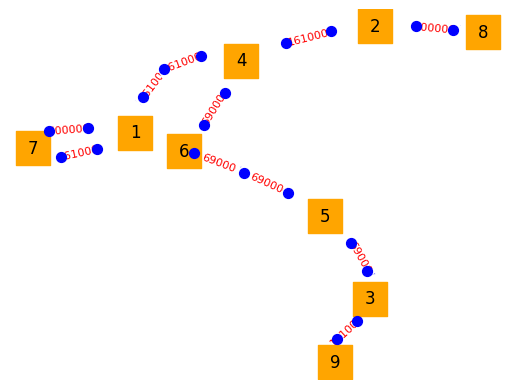

In [16]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(g)

# Split nodes by type
substations = [n for n, d in g.nodes(data=True) if d["type"] == "substation"]
towers      = [n for n, d in g.nodes(data=True) if d["type"] == "node_ref"]

# Draw each type separately
nx.draw_networkx_nodes(g, pos, nodelist=substations, node_color="orange", node_shape="s", node_size=600)
nx.draw_networkx_nodes(g, pos, nodelist=towers,      node_color="blue", node_shape="o", node_size=50)

# Create edge labels for line voltages
edge_labels = {(u, v): f"{d['voltage']}V" for u, v, d in g.edges(data=True) if 'voltage' in d}
nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels, font_color='blue', font_size=8)

# Only label substations
labels = {n: n for n, d in g.nodes(data=True) if d["type"] == "substation"}
nx.draw_networkx_labels(g, pos, labels=labels)

# Edge labels (u, v, k for multigraph)
edge_labels = {(u, v): d["voltage"] for u, v, k, d in g.edges(keys=True, data=True) if "voltage" in d}
nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels, font_color="red", font_size=8)


plt.axis("off")
plt.show()